<a href="https://colab.research.google.com/github/Caosbot/Treinos_Python/blob/Machine_Learning/Classifica%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_00 = pd.read_csv(r"F:\Cursos\DNC\Banco de dados\dataset-of-00s.csv") #Musicas dos anos 2000
df_10 = pd.read_csv(r"F:\Cursos\DNC\Banco de dados\dataset-of-10s.csv") #Musicas dos anos 2010
df_90 = pd.read_csv(r"F:\Cursos\DNC\Banco de dados\dataset-of-90s.csv") #Musicas dos anos 90

In [3]:
df = pd.concat([df_90,df_00,df_10])

In [4]:
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Misty Roses,Astrud Gilberto,spotify:track:50RBM1j1Dw7WYmsGsWg9Tm,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.00699,0.1680,0.543,116.211,158840,4,53.89523,6,0
1,Never Ever,All Saints,spotify:track:5FTz9qQ94PyUHETyAyfYZN,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.00000,0.0492,0.309,134.187,387573,4,32.16853,16,1
2,Soul Sermon,Gregg Karukas,spotify:track:6m24oe3lk1UMxq9zq4iPFi,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.49500,0.0809,0.265,93.982,237267,4,42.05369,9,0
3,Clarinet Marmalade - Live,Alton Purnell,spotify:track:5FOXuiLI6knVtgMUjWKj6x,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.92600,0.6750,0.763,114.219,375933,4,80.99693,10,0
4,До смерті і довше - Drum & Base and Rock Remix,Skryabin,spotify:track:6CxyIPTqSPvAPXfrIZczs4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.00339,0.1530,0.961,153.166,430653,4,25.57331,20,0


In [5]:
df.shape # Veirificando a qtd de linhas e colunas,

(17790, 19)

In [6]:
df['target'].isnull().sum() # Sem dadods faltantes

0

In [7]:
df['target'].value_counts(normalize=True) * 100 # Em porcentagem

target
0    50.0
1    50.0
Name: proportion, dtype: float64

## Granularidade

### Usando Groupby

In [8]:
df.groupby(['track', 'artist']).size().sort_values(ascending=False)

track                                  artist              
Falling                                Julee Cruise            12
Chebika - Claudio Mate Metal Remix     Stefano Patarnello       8
Feeling Punk - Asle Remix              Todd Terry               6
Spiegel im Spiegel                     Arvo Pärt                5
Until the Day I Die                    Story Of The Year        5
                                                               ..
He's Got The Whole World In His Hands  Doc & Merle Watson       1
He's Mine                              MoKenStef                1
Head (She's Just a...) [Rock Version]  Atom And His Package     1
Head Home                              Midlake                  1
雏鹰                                     窒息                       1
Length: 17362, dtype: int64

In [9]:
df.drop_duplicates(subset=['track', 'artist'], inplace=True)
df.shape

(17362, 19)

In [10]:
df['target'].value_counts(normalize=True) * 100 # Em porcentagem

target
1    50.224628
0    49.775372
Name: proportion, dtype: float64

### Direto drop_duplicates (Verifica todas as colunas)

In [11]:
len(df)-len(df.drop_duplicates()) #Verificando a diferença

0

In [12]:
# df.drop_duplicates(inplace=True)
# df['target'].value_counts(normalize=True) * 100 # Em porcentagem

## Features

In [13]:
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Misty Roses,Astrud Gilberto,spotify:track:50RBM1j1Dw7WYmsGsWg9Tm,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.00699,0.1680,0.543,116.211,158840,4,53.89523,6,0
1,Never Ever,All Saints,spotify:track:5FTz9qQ94PyUHETyAyfYZN,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.00000,0.0492,0.309,134.187,387573,4,32.16853,16,1
2,Soul Sermon,Gregg Karukas,spotify:track:6m24oe3lk1UMxq9zq4iPFi,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.49500,0.0809,0.265,93.982,237267,4,42.05369,9,0
3,Clarinet Marmalade - Live,Alton Purnell,spotify:track:5FOXuiLI6knVtgMUjWKj6x,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.92600,0.6750,0.763,114.219,375933,4,80.99693,10,0
4,До смерті і довше - Drum & Base and Rock Remix,Skryabin,spotify:track:6CxyIPTqSPvAPXfrIZczs4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.00339,0.1530,0.961,153.166,430653,4,25.57331,20,0


In [14]:
df.dtypes

track                object
artist               object
uri                  object
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature        int64
chorus_hit          float64
sections              int64
target                int64
dtype: object

In [15]:
def tipos (frame = pd.DataFrame):
  '''Printa os tipos das colunas de um dataframe '''
  df_col = frame.columns
  for col in df_col:
    print(f'{col} = {df[col].map(lambda x: type(x)).unique()}')

In [16]:
tipos(df)

track = [<class 'str'>]
artist = [<class 'str'>]
uri = [<class 'str'>]
danceability = [<class 'float'>]
energy = [<class 'float'>]
key = [<class 'int'>]
loudness = [<class 'float'>]
mode = [<class 'int'>]
speechiness = [<class 'float'>]
acousticness = [<class 'float'>]
instrumentalness = [<class 'float'>]
liveness = [<class 'float'>]
valence = [<class 'float'>]
tempo = [<class 'float'>]
duration_ms = [<class 'int'>]
time_signature = [<class 'int'>]
chorus_hit = [<class 'float'>]
sections = [<class 'int'>]
target = [<class 'int'>]


In [17]:
df.isnull().sum()

track               0
artist              0
uri                 0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
dtype: int64

In [18]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
count,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,1.736200e+04,17362.000000,17362.000000,17362.000000,17362.000000
mean,0.559860,0.655534,5.269036,-8.368586,0.652632,0.088807,0.240249,0.157978,0.196683,0.485989,121.053226,2.494776e+05,3.923050,40.964088,10.795473,0.502246
std,0.187469,0.246079,3.563331,5.302304,0.476148,0.092832,0.307832,0.308222,0.167195,0.255124,29.909889,1.119149e+05,0.378197,19.964160,4.744401,0.500009
min,0.057600,0.000251,0.000000,-49.253000,0.000000,0.022000,0.000000,0.000000,0.013000,0.000000,34.535000,1.592000e+04,0.000000,0.000000,1.000000,0.000000
25%,0.438000,0.505000,2.000000,-9.919000,0.000000,0.035700,0.009080,0.000000,0.093800,0.278250,97.149000,1.997632e+05,4.000000,27.902563,8.000000,0.000000
50%,0.577000,0.699000,5.000000,-6.913500,1.000000,0.050400,0.082700,0.000044,0.128000,0.487000,119.876000,2.331265e+05,4.000000,36.271890,10.000000,1.000000
75%,0.697000,0.856000,8.000000,-5.036000,1.000000,0.096700,0.378750,0.058800,0.257000,0.690000,140.003000,2.763132e+05,4.000000,48.324433,12.000000,1.000000
max,0.986000,0.999000,11.000000,1.137000,1.000000,0.956000,0.996000,0.998000,0.992000,0.996000,217.872000,4.170227e+06,5.000000,262.615400,169.000000,1.000000


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
#display(sns.pairplot(df, hue="target"));

## Correlação

In [21]:
df.corr(numeric_only=True)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
danceability,1.000000,0.079547,0.020302,0.267515,-0.056397,0.187636,-0.194841,-0.349111,-0.109281,0.535457,-0.118716,-0.115242,0.177744,-0.066383,-0.090907,0.431556
energy,0.079547,1.000000,0.021120,0.773543,-0.008728,0.131180,-0.733336,-0.249619,0.201618,0.291144,0.206553,-0.088570,0.172705,-0.006720,-0.132499,0.117765
key,0.020302,0.021120,1.000000,0.007618,-0.153838,0.027905,-0.022199,-0.017270,-0.002199,0.019862,-0.003238,0.009676,-0.002717,0.003174,0.001698,0.018331
loudness,0.267515,0.773543,0.007618,1.000000,0.016656,0.114683,-0.641656,-0.453169,0.105401,0.279348,0.166995,-0.131400,0.181857,-0.037466,-0.152349,0.325587
mode,-0.056397,-0.008728,-0.153838,0.016656,1.000000,-0.078042,0.021148,-0.052902,0.003108,-0.001089,0.024613,-0.049147,0.009249,-0.020418,-0.037367,0.037270
speechiness,0.187636,0.131180,0.027905,0.114683,-0.078042,1.000000,-0.106344,-0.125366,0.137592,0.072458,0.037671,-0.029736,0.037711,-0.003131,-0.020936,0.070972
acousticness,-0.194841,-0.733336,-0.022199,-0.641656,0.021148,-0.106344,1.000000,0.282381,-0.097353,-0.177628,-0.159021,0.051123,-0.178735,0.009614,0.093083,-0.260632
instrumentalness,-0.349111,-0.249619,-0.017270,-0.453169,-0.052902,-0.125366,0.282381,1.000000,-0.039401,-0.296400,-0.040159,0.138729,-0.113558,0.082667,0.099897,-0.467519
liveness,-0.109281,0.201618,-0.002199,0.105401,0.003108,0.137592,-0.097353,-0.039401,1.000000,-0.010216,0.034006,0.000114,0.017876,0.045560,-0.024413,-0.081944
valence,0.535457,0.291144,0.019862,0.279348,-0.001089,0.072458,-0.177628,-0.296400,-0.010216,1.000000,0.039768,-0.174687,0.140427,-0.070973,-0.130453,0.214187


In [22]:
corr = df.select_dtypes("number").corr()
corr

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
danceability,1.000000,0.079547,0.020302,0.267515,-0.056397,0.187636,-0.194841,-0.349111,-0.109281,0.535457,-0.118716,-0.115242,0.177744,-0.066383,-0.090907,0.431556
energy,0.079547,1.000000,0.021120,0.773543,-0.008728,0.131180,-0.733336,-0.249619,0.201618,0.291144,0.206553,-0.088570,0.172705,-0.006720,-0.132499,0.117765
key,0.020302,0.021120,1.000000,0.007618,-0.153838,0.027905,-0.022199,-0.017270,-0.002199,0.019862,-0.003238,0.009676,-0.002717,0.003174,0.001698,0.018331
loudness,0.267515,0.773543,0.007618,1.000000,0.016656,0.114683,-0.641656,-0.453169,0.105401,0.279348,0.166995,-0.131400,0.181857,-0.037466,-0.152349,0.325587
mode,-0.056397,-0.008728,-0.153838,0.016656,1.000000,-0.078042,0.021148,-0.052902,0.003108,-0.001089,0.024613,-0.049147,0.009249,-0.020418,-0.037367,0.037270
speechiness,0.187636,0.131180,0.027905,0.114683,-0.078042,1.000000,-0.106344,-0.125366,0.137592,0.072458,0.037671,-0.029736,0.037711,-0.003131,-0.020936,0.070972
acousticness,-0.194841,-0.733336,-0.022199,-0.641656,0.021148,-0.106344,1.000000,0.282381,-0.097353,-0.177628,-0.159021,0.051123,-0.178735,0.009614,0.093083,-0.260632
instrumentalness,-0.349111,-0.249619,-0.017270,-0.453169,-0.052902,-0.125366,0.282381,1.000000,-0.039401,-0.296400,-0.040159,0.138729,-0.113558,0.082667,0.099897,-0.467519
liveness,-0.109281,0.201618,-0.002199,0.105401,0.003108,0.137592,-0.097353,-0.039401,1.000000,-0.010216,0.034006,0.000114,0.017876,0.045560,-0.024413,-0.081944
valence,0.535457,0.291144,0.019862,0.279348,-0.001089,0.072458,-0.177628,-0.296400,-0.010216,1.000000,0.039768,-0.174687,0.140427,-0.070973,-0.130453,0.214187


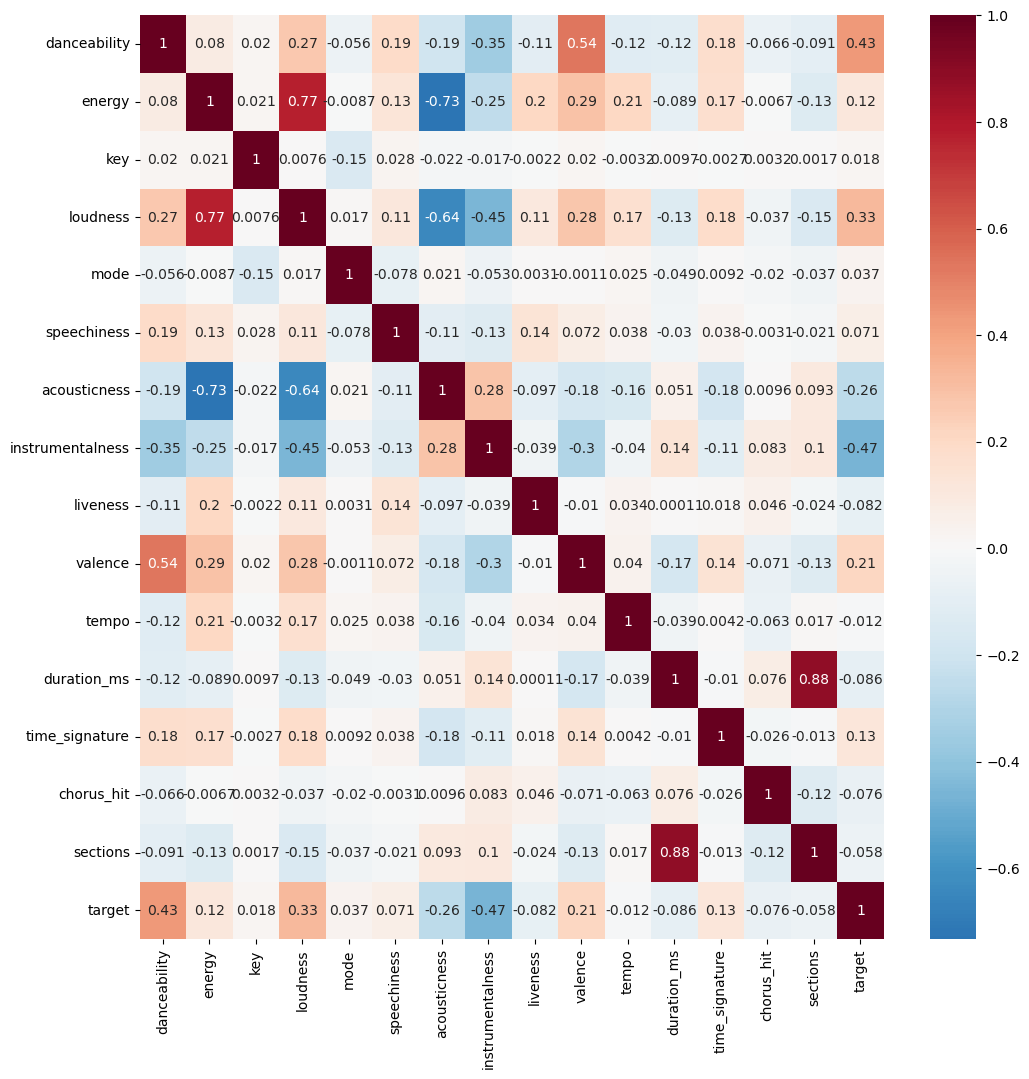

In [23]:
fig, ax = plt.subplots(figsize=(12,12))

sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True);

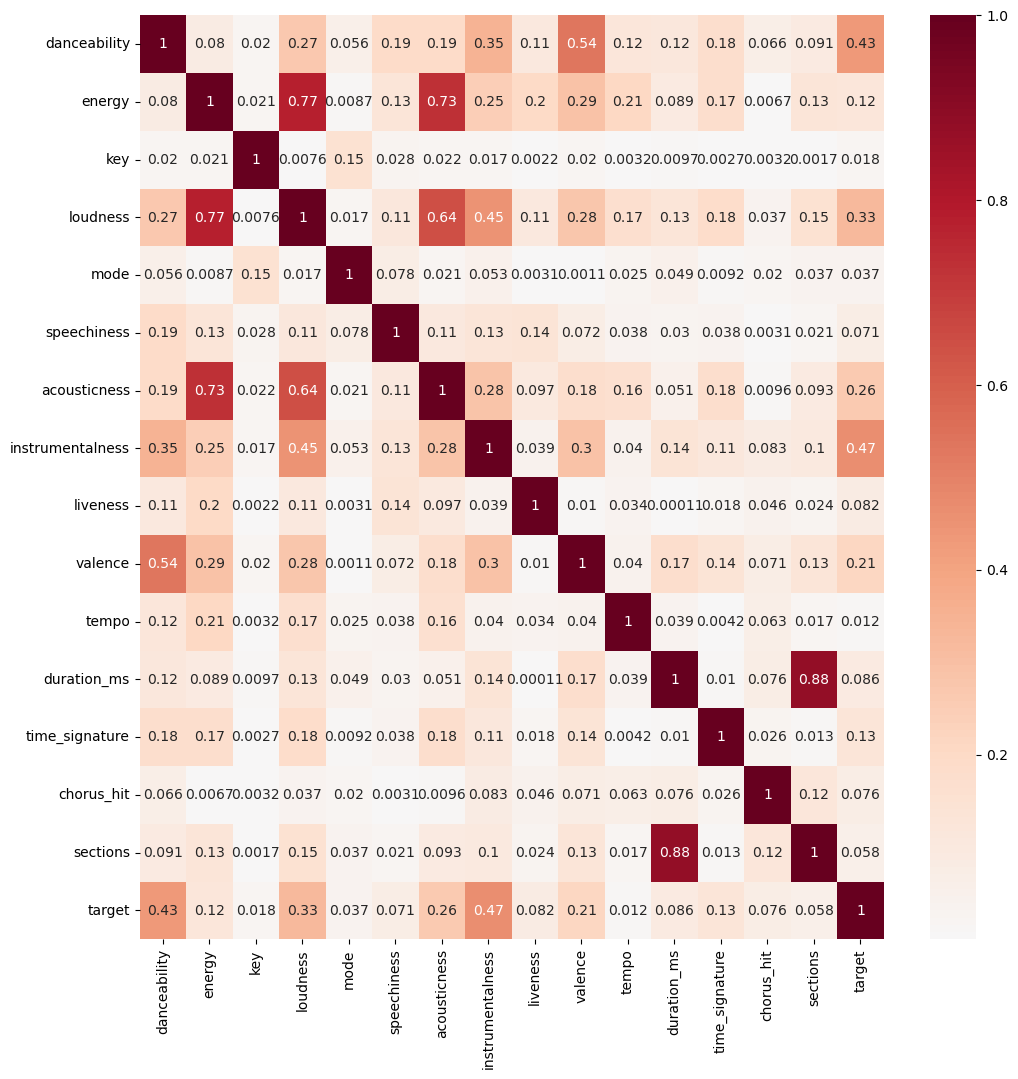

In [24]:
fig, ax = plt.subplots(figsize=(12,12))

sns.heatmap(corr.abs(), cmap='RdBu_r', center=0, annot=True);

## Separando os Dados

In [25]:
df.columns

Index(['track', 'artist', 'uri', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections', 'target'],
      dtype='object')

In [26]:
feature =['danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections']
target = 'target'

In [27]:
X = df[feature]
y = df[target]

In [28]:
print(f"Shape de X: {X.shape}\nShape de y: {y.shape}")

Shape de X: (17362, 15)
Shape de y: (17362,)


In [29]:
df.drop(['track', 'artist', 'uri', 'target'], axis=1)#axis=1 referencia a coluna

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections
0,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.006990,0.1680,0.5430,116.211,158840,4,53.89523,6
1,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.000000,0.0492,0.3090,134.187,387573,4,32.16853,16
2,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.495000,0.0809,0.2650,93.982,237267,4,42.05369,9
3,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.926000,0.6750,0.7630,114.219,375933,4,80.99693,10
4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.003390,0.1530,0.9610,153.166,430653,4,25.57331,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6393,0.172,0.358,9,-14.430,1,0.0342,0.886000,0.966000,0.3140,0.0361,72.272,150857,4,24.30824,7
6394,0.910,0.366,1,-9.954,1,0.0941,0.099600,0.000000,0.2610,0.7400,119.985,152000,4,32.53856,8
6395,0.719,0.804,10,-4.581,1,0.0355,0.013200,0.000003,0.1390,0.6050,119.999,227760,4,20.73371,7
6396,0.600,0.177,7,-16.070,1,0.0561,0.989000,0.868000,0.1490,0.5600,120.030,213387,4,21.65301,14


## Preparando Dados

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test =  train_test_split(X,y, test_size=0.3, random_state=42)

In [32]:
print(f"Features X_train", X_train.shape)
print(f"Features X_test", X_test.shape)

print(f"Features y_train", y_train.shape)
print(f"Features y_test", y_test.shape)

Features X_train (12153, 15)
Features X_test (5209, 15)
Features y_train (12153,)
Features y_test (5209,)


## Separando validação

In [33]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [34]:
print(f"Features X_val", X_val.shape)
print(f"Features X_test", X_test.shape)

Features X_val (2604, 15)
Features X_test (2605, 15)


### Validação Cruzada | K-folder

In [35]:
from sklearn.model_selection import KFold

In [36]:
KFold = KFold(n_splits=5, shuffle=True, random_state=42)

In [37]:
X_train, X_test, y_train, y_test =  train_test_split(X,y, test_size=0.3, random_state=42)

In [38]:
KFold.split(X_train)

<generator object _BaseKFold.split at 0x000001E54D07E9E0>

In [39]:
for train_index, test_index in KFold.split(X_train):
  print(test_index)

[    0     3     8 ... 12146 12151 12152]
[   10    12    20 ... 12122 12137 12147]
[   15    26    27 ... 12142 12145 12148]
[    2     6     7 ... 12141 12143 12149]
[    1     4     5 ... 12136 12139 12150]


In [40]:
for train_index, test_index in KFold.split(X_train):
  X_train_fold = X_train.iloc[train_index]
  y_train_fold = y_train.iloc[train_index]

  X_test_fold = X_train.iloc[train_index]
  y_test_fold = y_train.iloc[train_index]

  # treinar modelo com conjunto de treino
  # aplicar o modelo no conjunto de teste
  # medir o resultado no fold

In [41]:
from sklearn.model_selection import cross_val_score

In [42]:
# #model=

# scores = cross_val_score(model, X_train, y_train, cv=KFold, scoring='accuracy')

## Métricas de Classificação

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [44]:
y_true= [0,1,0,1,1,1,0,0,1,0]
y_pred= [0,1,1,0,1,0,0,1,0,0]

In [45]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f'Acuracia: {accuracy}')
print(f'Precisão: {precision}')
print(f'Recall: {recall}')
print(f'F1: {f1}')

Acuracia: 0.5
Precisão: 0.5
Recall: 0.4
F1: 0.4444444444444444


In [46]:
y_pred= [0,1,0,0,1,0,0,0,0,0] #Para testar

In [47]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f'Acuracia: {accuracy}')
print(f'Precisão: {precision}')
print(f'Recall: {recall}')
print(f'F1: {f1}')

Acuracia: 0.7
Precisão: 1.0
Recall: 0.4
F1: 0.5714285714285714


In [48]:
from sklearn.metrics import confusion_matrix

In [49]:
cm= confusion_matrix(y_true, y_pred)
cm

array([[5, 0],
       [3, 2]], dtype=int64)

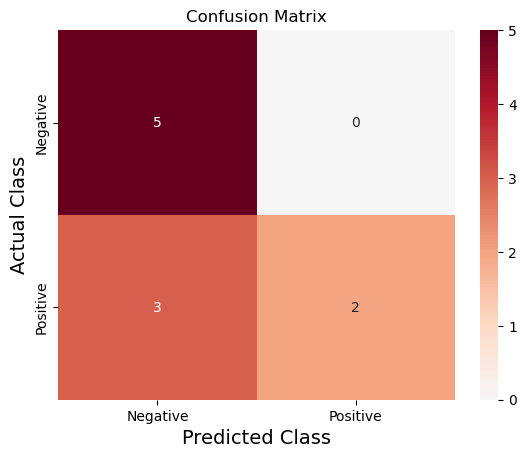

In [50]:
ax =sns.heatmap(cm, cmap='RdBu_r', center=0, annot=True, xticklabels= ['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
ax.set_xlabel("Predicted Class", fontsize=14)
ax.set_ylabel("Actual Class", fontsize=14)
ax.set_title('Confusion Matrix');

# Modelagem

## Pré -processamento

In [51]:
from sklearn.preprocessing import MinMaxScaler

In [52]:
scaler = MinMaxScaler()

# scaler.fit(X_train)
# scaler.transform(X_train)

scaler.fit_transform(X_train) #dataframe para numpy (Estrutura de array)

array([[0.34726411, 0.45425943, 0.        , ..., 0.75      , 0.14957272,
        0.01265823],
       [0.18892719, 0.9319076 , 0.81818182, ..., 0.75      , 0.22549797,
        0.05696203],
       [0.59931064, 0.54338037, 0.45454545, ..., 0.75      , 0.1769675 ,
        0.05696203],
       ...,
       [0.6068505 , 0.80273231, 0.27272727, ..., 0.75      , 0.10872645,
        0.05696203],
       [0.73610513, 0.83878123, 0.09090909, ..., 0.75      , 0.18461632,
        0.0443038 ],
       [0.37419216, 0.95093342, 0.18181818, ..., 0.75      , 0.0834239 ,
        0.03797468]])

In [53]:
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)# Como foi transformado em array, não há mais a referencia das colunas, assim columns=X.columns para voltar ao dataframe
X_train.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections
0,0.347264,0.454259,0.000000,0.785451,0.0,0.015203,0.758032,0.624248,0.256148,0.289157,0.214131,0.025285,0.75,0.149573,0.012658
1,0.188927,0.931908,0.818182,0.895841,1.0,0.069165,0.000011,0.000002,0.106557,0.152610,0.535666,0.065448,0.75,0.225498,0.056962
2,0.599311,0.543380,0.454545,0.851011,1.0,0.376874,0.007791,0.000033,0.379098,0.486948,0.778995,0.057407,0.75,0.176967,0.056962
3,0.755493,0.825764,0.727273,0.912247,1.0,0.211991,0.092671,0.000571,0.232582,0.430723,0.310852,0.045089,0.75,0.285022,0.050633
4,0.800732,0.543380,0.454545,0.807389,1.0,0.073876,0.566265,0.000000,0.105533,0.536145,0.530036,0.072918,0.75,0.331427,0.056962


In [54]:
scaler.transform(X_test)#dataframe para numpy (Estrutura de array)

array([[0.41619991, 0.63350266, 0.63636364, ..., 0.75      , 0.18621383,
        0.06962025],
       [0.73610513, 0.81074318, 0.45454545, ..., 0.75      , 0.12697229,
        0.06962025],
       [0.64993537, 0.78871328, 1.        , ..., 0.75      , 0.1498505 ,
        0.06329114],
       ...,
       [0.39034899, 0.32508414, 0.90909091, ..., 0.75      , 0.0692879 ,
        0.21518987],
       [0.26971133, 0.94292255, 0.        , ..., 0.5       , 0.25964506,
        0.05696203],
       [0.48082723, 0.97797011, 0.18181818, ..., 0.75      , 0.12486286,
        0.07594937]])

In [55]:
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)# Como foi transformado em array, não há mais a referencia das colunas, assim columns=X.columns para voltar ao dataframe
X_test.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections
0,0.416200,0.633503,0.636364,0.788630,0.0,0.027837,0.108434,0.872745,0.074180,0.227912,0.676005,0.090102,0.75,0.186214,0.069620
1,0.736105,0.810743,0.454545,0.775277,1.0,0.032548,0.241968,0.180361,0.081045,0.830321,0.449628,0.076268,0.75,0.126972,0.069620
2,0.649935,0.788713,1.000000,0.837233,0.0,0.127409,0.004378,0.729459,0.234631,0.295181,0.731450,0.086884,0.75,0.149851,0.063291
3,0.494830,0.918890,0.818182,0.855526,1.0,0.028801,0.059337,0.000000,0.289959,0.643574,0.547705,0.069521,0.75,0.152256,0.075949
4,0.429125,0.845791,0.636364,0.905274,0.0,0.067452,0.055422,0.000011,0.393443,0.565261,0.480619,0.048349,0.75,0.111271,0.069620


## Regressão Logística

In [56]:
from sklearn.linear_model import LogisticRegression

In [57]:
model = LogisticRegression(random_state=42)
model

LogisticRegression(random_state=42)

In [58]:
model.fit(X_train, y_train) #Treina o modelo

LogisticRegression(random_state=42)

### Predição

In [59]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [60]:
pd.Series(y_pred).value_counts()

1    3044
0    2165
Name: count, dtype: int64

In [61]:
pd.Series(y_pred).value_counts(normalize=True)

1    0.584373
0    0.415627
Name: proportion, dtype: float64

In [62]:
accuracy_score(y_test, y_pred)

0.7928585141101939

In [63]:
from sklearn.metrics import classification_report

In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.71      0.77      2606
           1       0.75      0.88      0.81      2603

    accuracy                           0.79      5209
   macro avg       0.80      0.79      0.79      5209
weighted avg       0.80      0.79      0.79      5209



## K-NN

In [65]:
from sklearn.neighbors import KNeighborsClassifier

In [66]:
model = KNeighborsClassifier()

In [67]:
model.fit(X_train, y_train)

KNeighborsClassifier()

In [68]:
y_pred = model.predict(X_test)

In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.71      0.76      2606
           1       0.75      0.86      0.80      2603

    accuracy                           0.78      5209
   macro avg       0.79      0.78      0.78      5209
weighted avg       0.79      0.78      0.78      5209



## Árvore de Decisão

In [70]:
from sklearn.tree import DecisionTreeClassifier

In [71]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75      2606
           1       0.75      0.75      0.75      2603

    accuracy                           0.75      5209
   macro avg       0.75      0.75      0.75      5209
weighted avg       0.75      0.75      0.75      5209



In [72]:
model = DecisionTreeClassifier(random_state=42, criterion='entropy')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.75      0.76      2606
           1       0.76      0.77      0.76      2603

    accuracy                           0.76      5209
   macro avg       0.76      0.76      0.76      5209
weighted avg       0.76      0.76      0.76      5209



In [73]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train)) # Ovefit

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6036
           1       1.00      1.00      1.00      6117

    accuracy                           1.00     12153
   macro avg       1.00      1.00      1.00     12153
weighted avg       1.00      1.00      1.00     12153



### Melhor modelo?

In [74]:
model = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=7)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.76      0.80      2606
           1       0.78      0.86      0.82      2603

    accuracy                           0.81      5209
   macro avg       0.81      0.81      0.81      5209
weighted avg       0.81      0.81      0.81      5209



In [75]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      6036
           1       0.80      0.88      0.84      6117

    accuracy                           0.83     12153
   macro avg       0.83      0.83      0.83     12153
weighted avg       0.83      0.83      0.83     12153



## Random Florest

In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.79      0.82      2606
           1       0.81      0.88      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.84      0.83      0.83      5209
weighted avg       0.84      0.83      0.83      5209



In [78]:
model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      2606
           1       0.81      0.88      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.84      0.83      0.83      5209
weighted avg       0.84      0.83      0.83      5209



In [79]:
model = RandomForestClassifier(n_estimators=50, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.79      0.83      2606
           1       0.81      0.87      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.83      0.83      0.83      5209
weighted avg       0.83      0.83      0.83      5209



## Gradient Boosting

In [80]:
from sklearn.ensemble import GradientBoostingClassifier

In [81]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [82]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82      2606
           1       0.80      0.89      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.84      0.83      0.83      5209
weighted avg       0.84      0.83      0.83      5209



In [83]:
model = GradientBoostingClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [84]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      2606
           1       0.80      0.89      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.84      0.83      0.83      5209
weighted avg       0.84      0.83      0.83      5209



In [85]:
model = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.05)
model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, random_state=42)

In [86]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      2606
           1       0.79      0.89      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.83      0.83      0.83      5209
weighted avg       0.83      0.83      0.83      5209



# Rede Neural (MLP)

## Contrução básica

In [87]:
from sklearn.neural_network import MLPClassifier

 1 camada com 100 neuronios, ativaçao relu, 200 iterações

In [88]:
model = MLPClassifier(random_state=42)

In [89]:
model.fit(X_train, y_train)

C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(random_state=42)

In [90]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.81      2606
           1       0.79      0.90      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.83      0.83      0.83      5209
weighted avg       0.83      0.83      0.83      5209



In [91]:
model = MLPClassifier(hidden_layer_sizes=(100,100), random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.78      0.82      2606
           1       0.80      0.88      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.83      0.83      0.83      5209
weighted avg       0.83      0.83      0.83      5209



C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [92]:
model = MLPClassifier(hidden_layer_sizes=(100,), activation="tanh",random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80      2606
           1       0.77      0.91      0.83      2603

    accuracy                           0.82      5209
   macro avg       0.83      0.82      0.82      5209
weighted avg       0.83      0.82      0.82      5209



C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## Avaliando as iterações ao longo do aprendizado da Rede Neural

In [93]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.10, random_state=42)

In [94]:
model = MLPClassifier(max_iter=1, warm_start=True, hidden_layer_sizes=(100,), activation="relu",random_state=42)
max_iterations = 1000

accuracy_val_result =[]
accuracy_train_result =[]

for iter in range(max_iterations):
  model.fit(X_train, y_train);

  y_pred_val = model.predict(X_val)
  y_pred_train = model.predict(X_train)

  accuracy_val = accuracy_score(y_val, y_pred_val)
  accuracy_val_result.append(accuracy_val)

  accuracy_train =   accuracy_score(y_train, y_pred_train)
  accuracy_train_result.append(accuracy_train)

C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn

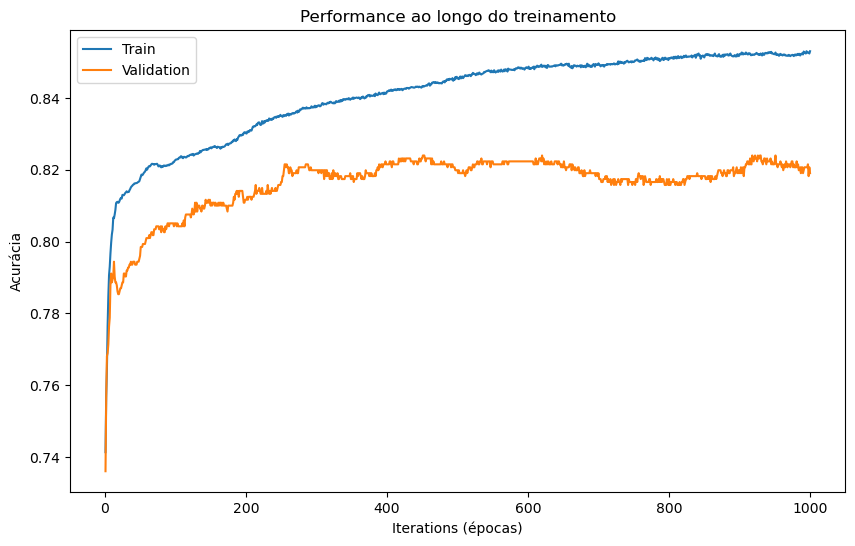

In [95]:
plt.figure(figsize=(10,6))

plt.plot(range(1, max_iterations+1), accuracy_train_result, label="Train")
plt.plot(range(1, max_iterations+1), accuracy_val_result, label="Validation")

plt.xlabel("Iterations (épocas)")
plt.ylabel("Acurácia")

plt.title("Performance ao longo do treinamento")

plt.legend()
plt.show()

# Comparando Modelos

## Validação Cruzada

In [96]:
models = {
  "Logistic Regression": LogisticRegression(random_state=42),
  "K-NN": KNeighborsClassifier(),
  "Decision Tree": DecisionTreeClassifier(random_state=42),
  "Random Forest": RandomForestClassifier(random_state=42),
  "Gradient Booster": GradientBoostingClassifier(random_state=42),
  "Neural Network": MLPClassifier(hidden_layer_sizes=(100,), activation="relu",random_state=42)
}

In [97]:
from sklearn.model_selection import cross_val_score

In [98]:
result_mean = []
result_std = []
result_names = []

for name_model, model in models.items():
  print(f"Nome do Modelo:{name_model}")

  cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
  result_mean.append(cv_scores.mean())
  result_std.append(cv_scores.std())
  result_names.append(name_model)

Nome do Modelo:Logistic Regression
Nome do Modelo:K-NN
Nome do Modelo:Decision Tree
Nome do Modelo:Random Forest
Nome do Modelo:Gradient Booster
Nome do Modelo:Neural Network


C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\david\.conda\envs\GPU\lib\site-packages

In [99]:
df_results = pd.DataFrame({
    "Modelo": result_names,
    "Acurácia Média": result_mean,
    "Acurácia Std": result_std
})
df_results.sort_values(ascending=False, by="Acurácia Média" )

,Modelo,Acurácia Média,Acurácia Std
4,Gradient Booster,0.833136,0.007477
3,Random Forest,0.832862,0.007961
5,Neural Network,0.820793,0.008514
0,Logistic Regression,0.794734,0.007753
1,K-NN,0.782482,0.005086
2,Decision Tree,0.757978,0.014473


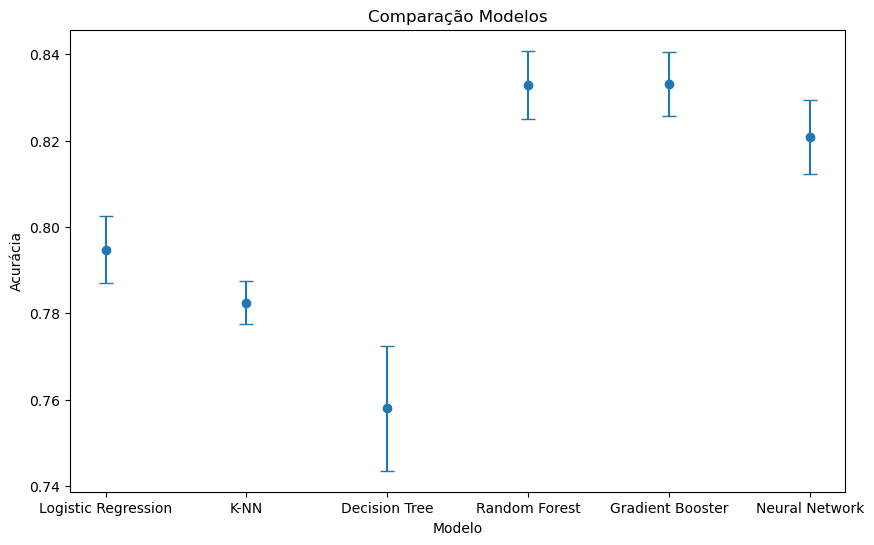

In [100]:
plt.figure(figsize=(10,6))
plt.errorbar(df_results["Modelo"], df_results['Acurácia Média'], yerr=df_results['Acurácia Std'], fmt='o', capsize=5)

plt.xlabel("Modelo")
plt.ylabel("Acurácia")

plt.title("Comparação Modelos")

plt.show()

# Tunning de Hiperparametros

In [101]:
k_list = [1, 3, 5, 7, 9, 15, 21, 25]

In [102]:
results = []

for k in k_list:
  scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=5, scoring="accuracy")
  results.append({
      'k':k,
      "acuracia": scores.mean()
  })


In [103]:
results

[{'k': 1, 'acuracia': 0.7389602763211899},
 {'k': 3, 'acuracia': 0.7691327513669356},
 {'k': 5, 'acuracia': 0.7824822430031539},
 {'k': 7, 'acuracia': 0.7886073515680575},
 {'k': 9, 'acuracia': 0.7908020971521095},
 {'k': 15, 'acuracia': 0.796470836060517},
 {'k': 21, 'acuracia': 0.7972931290014369},
 {'k': 25, 'acuracia': 0.7959220974196034}]

In [105]:
df_results_knn = pd.DataFrame(results)
df_results_knn

,k,acuracia
0,1,0.738960
1,3,0.769133
2,5,0.782482
3,7,0.788607
4,9,0.790802
5,15,0.796471
6,21,0.797293
7,25,0.795922


<Axes: xlabel='k', ylabel='acuracia'>

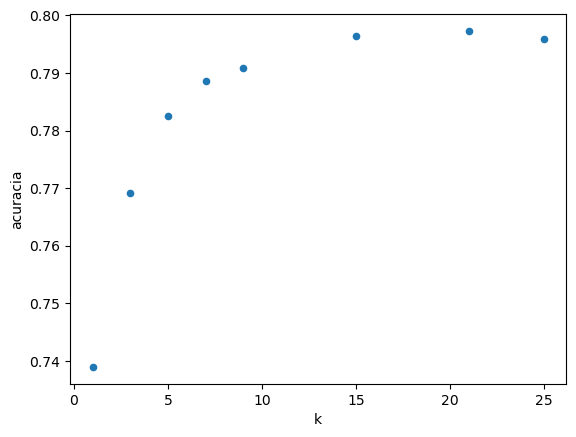

In [106]:
df_results_knn.plot(x='k', y='acuracia', kind='scatter')

## Para árvore - Grid Search

In [118]:
criterion_list = ['gini', 'entropy']
max_depth_list = [None, 3, 5, 7, 10, 15]
min_samples_split_list = [2, 6, 20]

In [119]:
count=0

for criterion in criterion_list:
  for max_depth in max_depth_list:
    for min_samples_split in min_samples_split_list:
      print(f"Criterion: {criterion}, Max_depht: {max_depth}, Min_sample_split: {min_samples_split}")
      count+=1
print(f"Count: {count}")

Criterion: gini, Max_depht: None, Min_sample_split: 2
Criterion: gini, Max_depht: None, Min_sample_split: 6
Criterion: gini, Max_depht: None, Min_sample_split: 20
Criterion: gini, Max_depht: 3, Min_sample_split: 2
Criterion: gini, Max_depht: 3, Min_sample_split: 6
Criterion: gini, Max_depht: 3, Min_sample_split: 20
Criterion: gini, Max_depht: 5, Min_sample_split: 2
Criterion: gini, Max_depht: 5, Min_sample_split: 6
Criterion: gini, Max_depht: 5, Min_sample_split: 20
Criterion: gini, Max_depht: 7, Min_sample_split: 2
Criterion: gini, Max_depht: 7, Min_sample_split: 6
Criterion: gini, Max_depht: 7, Min_sample_split: 20
Criterion: gini, Max_depht: 10, Min_sample_split: 2
Criterion: gini, Max_depht: 10, Min_sample_split: 6
Criterion: gini, Max_depht: 10, Min_sample_split: 20
Criterion: gini, Max_depht: 15, Min_sample_split: 2
Criterion: gini, Max_depht: 15, Min_sample_split: 6
Criterion: gini, Max_depht: 15, Min_sample_split: 20
Criterion: entropy, Max_depht: None, Min_sample_split: 2
Crit

In [123]:
from sklearn.model_selection import GridSearchCV

In [124]:
params_grid = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [None, 3, 5, 7, 10, 15],
    'min_samples_split' : [2, 6, 20]
}

In [129]:
model = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(model, params_grid, cv=5, scoring="accuracy")

In [130]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7, 10, 15],
                         'min_samples_split': [2, 6, 20]},
             scoring='accuracy')

In [131]:
grid.best_score_

0.8076247879901931

In [132]:
grid.best_params_

{'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 20}

In [135]:
df_results_tree=pd.DataFrame(grid.cv_results_)

In [136]:
df_results_tree.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.123311,0.010744,0.002416,0.000804,gini,NaN,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.763254,0.747715,0.758573,0.738912,0.781436,0.757978,0.014473,33
1,0.123539,0.014647,0.002200,0.000396,gini,NaN,6,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.766910,0.750000,0.751257,0.730224,0.780521,0.755783,0.016988,35
2,0.131081,0.012748,0.002003,0.000006,gini,NaN,20,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.772852,0.762797,0.771376,0.751257,0.785094,0.768675,0.011245,32
3,0.032409,0.005690,0.002803,0.000979,gini,3.0,2,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.770567,0.767367,0.782350,0.767261,0.770919,0.771693,0.005546,25
4,0.028694,0.003816,0.001817,0.000414,gini,3.0,6,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.770567,0.767367,0.782350,0.767261,0.770919,0.771693,0.005546,25


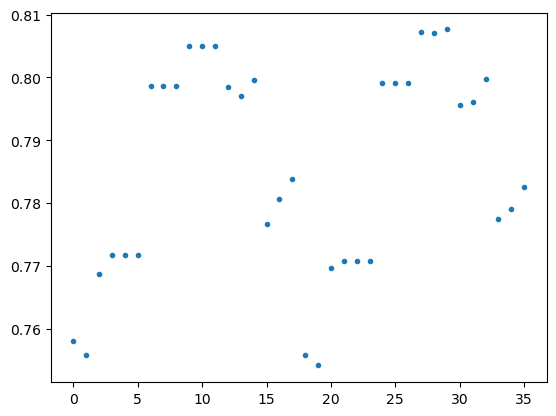

In [138]:
df_results_tree['mean_test_score'].plot(style = ".");

## Random_search

In [169]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

In [139]:
from scipy.stats import uniform, randint

In [190]:
param_dist_gb = {
    'subsample': np.random.uniform(low=0.5, high=1.0, size=1),
    'n_estimators': randint(50, 500),
    'max_depth': randint(3, 10),
    "min_samples_split": randint(2, 20)
}

In [191]:
model= GradientBoostingClassifier(random_state=42)

In [192]:
random_search = RandomizedSearchCV(model, param_dist_gb, n_iter=20, cv=5, scoring="accuracy", random_state=42, n_jobs=-1)

In [193]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E55CD1B070>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E55CC8CE50>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E55B4EC6A0>,
                                        'subsample': array([0.97114453])},
                   random_state=42, scoring='accuracy')

In [194]:
print(f"Melhores parâmetros:, {random_search.best_params_}")
print(f"Melhor score:, {random_search.best_score_}")

Melhores parâmetros:, {'max_depth': 9, 'min_samples_split': 4, 'n_estimators': 255, 'subsample': 0.9711445268615376}
Melhor score:, 0.8369761403807943


In [195]:
df_results_gb = pd.DataFrame(random_search.cv_results_)
df_results_gb.shape

(20, 17)